[[131  12]
 [  9 148]]
WITH K=1


[[131  12]
 [  9 148]]


              precision    recall  f1-score   support

           0       0.94      0.92      0.93       143
           1       0.93      0.94      0.93       157

    accuracy                           0.93       300
   macro avg       0.93      0.93      0.93       300
weighted avg       0.93      0.93      0.93       300

WITH K=23


[[129  14]
 [  4 153]]


              precision    recall  f1-score   support

           0       0.97      0.90      0.93       143
           1       0.92      0.97      0.94       157

    accuracy                           0.94       300
   macro avg       0.94      0.94      0.94       300
weighted avg       0.94      0.94      0.94       300



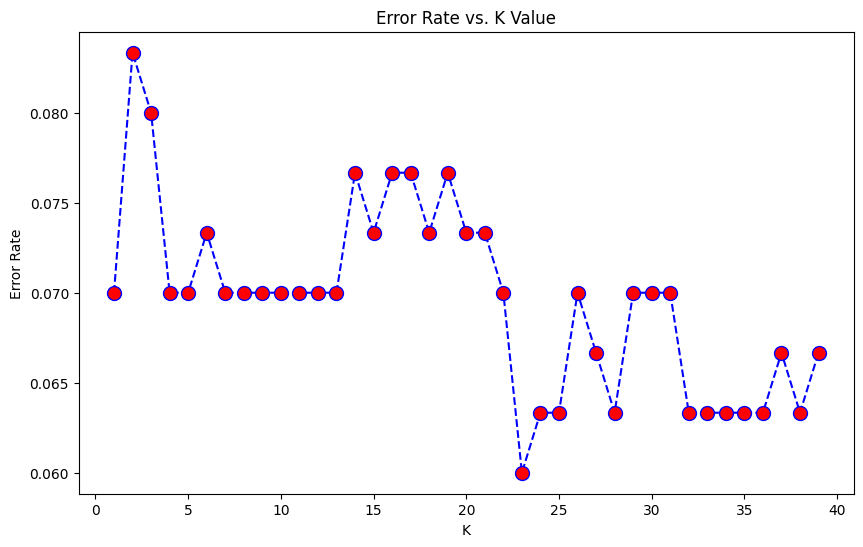

In [ ]:
#K Nearest Neighbors with Python
#Import Libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

#Load the Data
df = pd.read_csv("Classified Data.txt",index_col=0)
df.head()

#Standardize the Variables
#Because the KNN classifier predicts the class of a given test observation
#by identifying the observations that are nearest to it, the scale of the
#variables matters. Any variables that are on a large scale will have a much
#larger effect on the distance between the observations, and hence on the KNN
#classifier, than variables that are on a small scale.

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(df.drop('TARGET CLASS',axis=1))
scaled_features = scaler.transform(df.drop('TARGET CLASS',axis=1))
df_feat = pd.DataFrame(scaled_features,columns=df.columns[:-1])
df_feat.head()


#Train-Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(scaled_features,df['TARGET CLASS'],test_size=0.30)


## Using KNN
#Remember that we are trying to come up with a model to predict whether someone
#will TARGET CLASS or not. We'll start with k=1.

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=1)

knn.fit(X_train,y_train) # training the data
KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
           metric_params=None, n_jobs=1, n_neighbors=1, p=2,
           weights='uniform')
pred = knn.predict(X_test)

#Predicting and evavluations
#Let's evaluate our knn model.

from sklearn.metrics import classification_report,confusion_matrix
print(confusion_matrix(y_test,pred))
#Let's go ahead and use the elbow method to pick a good K Value:
error_rate = []
# Will take some time
for i in range(1,40):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train,y_train)
    pred_i = knn.predict(X_test)
    error_rate.append(np.mean(pred_i != y_test))
plt.figure(figsize=(10,6))
plt.plot(range(1,40),error_rate,color='blue', linestyle='dashed', marker='o',markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')

#Here we can see that that after arouns K>23 the error rate just tends to hover
#around 0.06-0.05 Let's retrain the model with that and check the classification report!

# FIRST A QUICK COMPARISON TO OUR ORIGINAL K=1
knn = KNeighborsClassifier(n_neighbors=1)

knn.fit(X_train,y_train)
pred = knn.predict(X_test)

print('WITH K=1')
print('\n')
print(confusion_matrix(y_test,pred))
print('\n')
print(classification_report(y_test,pred))



# NOW WITH K=23
knn = KNeighborsClassifier(n_neighbors=23)

knn.fit(X_train,y_train)
pred = knn.predict(X_test)

print('WITH K=23')
print('\n')
print(confusion_matrix(y_test,pred))
print('\n')
print(classification_report(y_test,pred))

